In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection


pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


Additional examples for long transients due to ghosts

In [ ]:
# set parameters
g_Farjami=1.5

# simulate trajectory 
t_end = 700
dt = 0.1
timesteps = np.linspace(0,t_end,int(t_end/dt))
sol = solve_ivp(mod.sys_Farjami2021, (0, t_end), [0.6,0.8,0.8],
                    t_eval=timesteps, args=(g_Farjami,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.sys_Farjami2021,g_Farjami,dt,Trj,peak_kwargs={"prominence":2,"width":1000},eigval_NN_sorting=True,
                                  ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# plot trajectory

fig = plt.figure(figsize=(5*inCm,7*inCm))
ax = fig.add_subplot(projection='3d')

simX,simY,simZ = sol.y[:,::2]
        
col = fun.euklideanVelocity(sol.y[:,::2].T, 1)
cmBounds = [col.min(), col.max()]
# cmBounds = [1e-6, 0.01]
norm = plt.Normalize(cmBounds[0],cmBounds[1])
cmap=plt.get_cmap('cool')
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)


for i in range(len(simX)-1): #
    ax.plot3D(simX[i],simY[i],simZ[i] ,'o', ms=2,color=np.asarray(cmap(norm(col[i]))[0:3]))
            
fun.noBackground(ax)
ax.view_init(20,45)

# plot ghost
for g in ghostSeq:
    gx,gy,gz = g["position"]
    ax.plot(gx,gy,gz,'ow',mec='m',markersize=7,alpha=0.75)

# add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.1,
    shrink=0.5,
    aspect=20
)
cbar.set_label("velocity (a.u.)")

# #labels
ax.set_xlabel('x$_1$'); ax.set_ylabel('x$_2$');ax.set_zlabel('x$_3$')

# plt.savefig("SFigure_GhostCycle_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID
# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(5*inCm,6*inCm)
plt.figure(fig)
# plt.savefig("SFigure4b_GhostCycle_pQ.svg")
plt.show()

# eigenvalues across trajectories

fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[0].set_ylim(-0.205,-0.195)
for i in range(3): axes[i].set_xlim(0,22)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[2].set_ylabel('$\\lambda_3$')
axes[2].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
# plt.savefig("SFigure_GhostCycle_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[2].set_ylim(-0.205,-0.195)
for i in range(3): axes[i].set_xlim(0,22)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[2].set_ylabel('$\\lambda_3$')
axes[2].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
# plt.savefig("SFigure_GhostCycle_evsQ2.svg")
plt.show()

In [ ]:
# set parameters
gamma=0.5
K=0.05
E=0.9

parameters_strogatz = [gamma, K, E]

# simulate trajectory 
t_end = 55
dt = 0.01
timesteps = np.linspace(0,t_end,int(t_end/dt))
sol = solve_ivp(mod.strogatz_model, (0, t_end), [-5,-5.5],
                    t_eval=timesteps, args=(parameters_strogatz,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.strogatz_model,parameters_strogatz,dt,Trj,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# phase space
xmin=-5;xmax=1
ymin=-5;ymax=1

Ng=150
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.strogatz_model,parameters_strogatz,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.strogatz_model(t,z,parameters_strogatz)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.7,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0,:],sol.y[1,:],'-',color='ivory',lw=2)

# plot ghost
for g in ghostSeq:
    gx,gy = g["position"]
    ax.plot(gx,gy,'ow',mec='m',markersize=7,alpha=0.75,label='ghost' if g==ghostSeq[0] else None)

# plot Q-value
vmin = 1e-4 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# # nullclines
# v = lambda u: u - u**3 # u-Nullcline # u=x, v=y
# u = lambda v: b*v-a # v-Nullcline
# ax.plot(x_range,v(x_range),'-b',label='u nullcline')
# ax.plot(u(y_range),y_range,'--b',label='v nullcline')
# nullclines
f1,f2 = mod.strogatz_model(0,jnp.array([Xg,Yg]),parameters_strogatz)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot \psi = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot \phi = 0$')


# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel(r'$\psi$'); ax.set_ylabel(r'$\phi$')
ax.set_xlim(xmin,xmax); ax.set_xticks([-4,-2,0])
ax.set_ylim(ymin,ymax); ax.set_yticks([-4,-2,0])
ax.legend(fontsize=7)
plt.savefig("CDW_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("CDW_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2*inCm)
# axes[0].set_xlim(0,29)
# axes[1].set_xlim(0,29)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("CDW_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.1*inCm)
# axes[0].set_xlim(0,29)
# axes[1].set_xlim(0,29)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("CDW_evsQ2.svg")
plt.show()

Higher dimensional & unstable ghosts

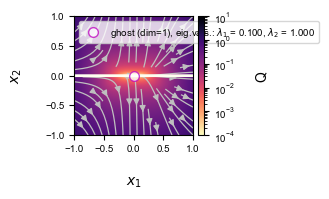

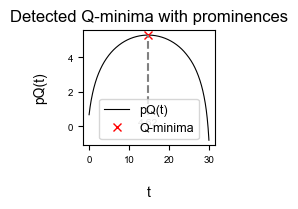

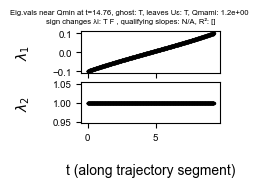

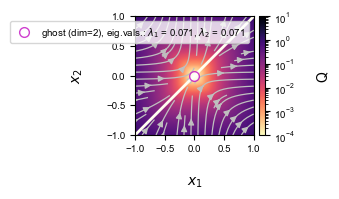

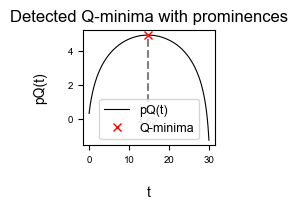

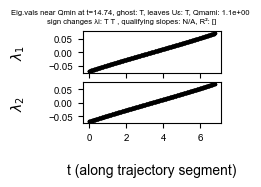

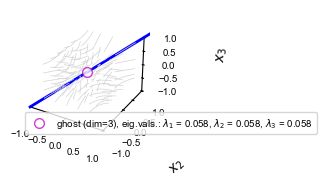

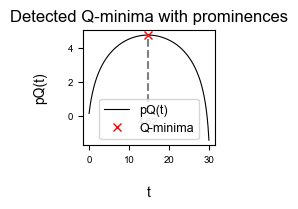

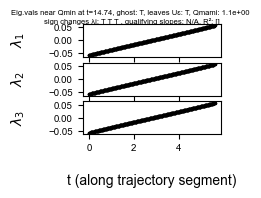

In [ ]:
# 2D saddle node ghosts


# paras = [[0.01,3,3,0,[-1,-1,-1]]]

paras = [[0.01,2,1,1,[-1,0]],    
        [0.01,2,2,0,[-1,-1]],
        [0.01,3,3,0,[-1,-1,-1]]    
        ]


for p in paras:

    mu,n,j,k,IC = p

    parameters_SNjk = [mu,n,j,k]

    # simulate trajectory 
    t_end = 30
    dt = 0.01
    timesteps = np.linspace(0,t_end,int(t_end/dt))
    sol = solve_ivp(mod.SN_jk, (0, t_end), IC, t_eval=timesteps, args=(parameters_SNjk,),method='RK45')

    # run ghostID
    Trj=sol.y.T
    ghostSeq, ctrlPlots = gid.ghostID(mod.SN_jk,parameters_SNjk,dt,Trj,peak_kwargs={"prominence":0},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

    # phase space
    xmin=-1;xmax=1
    ymin=-1;ymax=1
    zmin=-1;zmax=1

    if n==2:

        Ng=100
        x_range=np.linspace(xmin,xmax,Ng)
        y_range=np.linspace(ymin,ymax,Ng)
        grid_ss = np.meshgrid(x_range, y_range)
        Xg,Yg=grid_ss

        Q, coords = gid.qOnGrid(mod.SN_jk,parameters_SNjk,coords=[x_range,y_range], jit=True)

        plt.figure(figsize=(4.25*inCm,6*inCm))
        ax = plt.gca()

        def flow_model(t,z): 
                return mod.SN_jk(t,z,parameters_SNjk) 
        U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 


        ax.streamplot(
            Xg, Yg,
            U,V,
            density=0.6,
            color=[0.75, 0.75, 0.75, 1],
            arrowsize=0.9,
            linewidth=0.9)

        # plot trajectory
        ax.plot(sol.y[0,:],sol.y[1,:],'-',color='ivory',lw=2)

        # plot ghost
        for g in ghostSeq:
            gx,gy = g["position"]
            ax.plot(
            gx, gy, 'ow',
            mec='m', markersize=7, alpha=0.75,
            label=(
                f'ghost (dim={g["dimension"]})'
                + ", ".join(rf"$\lambda_{i+1}$ = {np.real(val):.3f}"
                            for i, val in enumerate(g["eigenvalues_qmin"]))
            ) if g == ghostSeq[0] else None
            )
    
        # plot Q-value
        vmin = 1e-4 # Define log scale range 
        vmax = 10 # Avoid zero or negative values 
        im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

        # # add colorbar
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(im, cax=cax,label="Q")

    if n==3:

        fig = plt.figure(figsize=(4.25*inCm,6*inCm))
        # ax = plt.gca()
        ax = fig.add_subplot(projection='3d')
        fun.noBackground(ax)

        ax.plot(sol.y[0,:],sol.y[1,:],sol.y[2,:],'-',color='blue',lw=2)

    
        for x in np.linspace(-0.75,0.5,5):
            for y in np.linspace(-0.75,0.5,5):
                for z in np.linspace(-0.75,0.5,5):
                    IC = [x,y,z]
                    # print(IC)
                    t_end = 0.8
                    dt = 0.025
                    timesteps = np.linspace(0,t_end,int(t_end/dt))
                    sol = solve_ivp(mod.SN_jk, (0, t_end), IC, t_eval=timesteps, args=(parameters_SNjk,),method='RK45')
                    ax.plot(sol.y[0,:],sol.y[1,:],sol.y[2,:],'-',color='lightgray',lw=0.5)
       

             # plot ghost
        for g in ghostSeq:
            gx,gy,gz = g["position"]
            ax.plot(
            gx, gy,gz, 'ow',
            mec='m', markersize=7, alpha=0.75,
            label=(
                f'ghost (dim={g["dimension"]})'
                + ", ".join(rf"$\lambda_{i+1}$ = {np.real(val):.3f}"
                            for i, val in enumerate(g["eigenvalues_qmin"]))
            ) if g == ghostSeq[0] else None
            )

    # #labels, limits, legend
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    if n==3: ax.set_zlabel(r'$x_3$')
    ax.set_xlim(xmin,xmax); #ax.set_xticks([-4,-2,0])
    ax.set_ylim(ymin,ymax);# ax.set_yticks([-4,-2,0])
    if n==3: ax.set_zlim(zmin,zmax)
    ax.legend(fontsize=7)
    plt.savefig(f"ghost_type_{j},{k}_phaseSpace.svg")
    plt.show()

    # Plot control outputs from ghostID

    # pQ timeseries and Q-minima
    fig, ax = ctrlPlots[0]
    fig.set_size_inches(4.5*inCm,5.5*inCm)
    plt.figure(fig)
    plt.savefig(f"ghost_type_{j},{k}_pQ.svg")
    plt.show()

    # eigenvalues across trajectories
    fig, axes = ctrlPlots[1]
    suptxt = fig._suptitle.get_text()
    fig.suptitle(suptxt,fontsize=5.5)
    fig.set_size_inches(5*inCm,3.75*inCm)
    
    # axes[0].set_xlim(0,29)
    # axes[1].set_xlim(0,29)
    axes[0].set_ylabel('$\\lambda_1$')
    axes[1].set_ylabel('$\\lambda_2$')
    if n==3: axes[2].set_ylabel('$\\lambda_3$')
    axes[n-1].set_xlabel('t (along trajectory segment)')
    plt.figure(fig)
    plt.savefig(f"ghost_type_{j},{k}_evsQ1.svg")
    plt.show()


Additional example of long transients due to saddles

In [ ]:
#May-Leonard Heteroclinic Cycle
# set parameters

alpha = 0.8
beta = 1.29
parameters_ML=[alpha,beta]

# simulate trajectory 
t_end = 1200
dt = 0.1
timesteps = np.linspace(0,t_end,int(t_end/dt))
sol = solve_ivp(mod.May_Leonard, (0, t_end), [0.6,0.6,0.1],
                    t_eval=timesteps, args=(parameters_ML,),method='RK45',rtol=1e-10,atol=1e-10)


# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.May_Leonard,parameters_ML,dt,Trj,1e-5,peak_kwargs={"prominence":2,"width":500},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True},eigval_NN_sorting=True) #
if len(ghostSeq)==0: print("No ghosts for May-Leonard model identified.")

# plot trajectory
fig = plt.figure(figsize=(6*inCm,3*inCm))
plt.plot(sol.t,sol.y[1,:],'-')
plt.ylabel('N$_1$'); plt.xlabel('t')

fig = plt.figure(figsize=(4.5*inCm,6.3*inCm))
ax = fig.add_subplot(projection='3d')

simX,simY,simZ = sol.y[:,::4]
        
col = fun.euklideanVelocity(sol.y[:,::4].T, 1)
cmBounds = [1e-4, 1e-1]

norm = LogNorm(vmin=cmBounds[0], vmax=cmBounds[1])
cmap=plt.get_cmap('cool')
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)


for i in range(len(simX)-1): #
    ax.plot3D(simX[i],simY[i],simZ[i] ,'o', ms=2,color=np.asarray(cmap(norm(col[i]))[0:3]))
            
fun.noBackground(ax)
ax.view_init(20,45)

# add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.1,
    shrink=0.5,
    aspect=20
)
cbar.set_label("velocity (a.u.)")

# #labels
ax.set_xlabel('N$_1$'); ax.set_ylabel('N$_2$');ax.set_zlabel('N$_3$')

plt.savefig("HC_phaseSpace.svg")
plt.show()


# Plot control outputs from ghostID
# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("HC_pQ.svg")
plt.show()

# eigenvalues across trajectories

fig, axes = ctrlPlots[4]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5,3.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[1].set_ylim(-1.01,-0.99)
for i in range(3): axes[i].set_xlim(-1,215)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[2].set_ylabel('$\\lambda_3$')
axes[2].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("HC_evsQ4.svg")
plt.show()


Additional examples of long transients due to slow-fast dynamics

In [ ]:
# Toy model for slow-fast systems (Kuehn 2015)
# set parameters
eps=0.1
parameters_kuehn =  eps

# simulate trajectories
dt = 0.01
timesteps = np.linspace(0,100,int(100/dt))
sol1 = solve_ivp(mod.Kuehn_toyModel, (0, 100), [-0.5,-0.25],
                    t_eval=timesteps, args=(parameters_kuehn,),method='RK45')
sol2 = solve_ivp(mod.Kuehn_toyModel, (0, 100), [0.5,0.15],
                    t_eval=timesteps, args=(parameters_kuehn,),method='RK45')

# run ghostID
Trj1=sol1.y.T
ghostSeq1, ctrlPlots1 = gid.ghostID(mod.Kuehn_toyModel,parameters_kuehn,dt,Trj1,0.005,peak_kwargs={"prominence":0,"width":100},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

Trj2=sol2.y.T
ghostSeq2, ctrlPlots2 = gid.ghostID(mod.Kuehn_toyModel,parameters_kuehn,dt,Trj2,0.005,peak_kwargs={"prominence":0,"width":100},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq1)==0 and len(ghostSeq2)==0: print("No ghosts in Kuehn slow-fast toy model identified.")

# plot phase space
xmin=-0.5;xmax=0.5
ymin=-0.5;ymax=0.5

Ng=160
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.Kuehn_toyModel,parameters_kuehn,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.Kuehn_toyModel(t,z,parameters_kuehn)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol1.y[0],sol1.y[1],'-',color='green',lw=2)
ax.plot(sol2.y[0],sol2.y[1],'-',color='magenta',lw=2)

# slow manifold
ax.plot(0*y_range+eps,y_range,':',color='blue',label='slow manifold')

# plot Q-value
vmin = 1e-5 # Define log scale range 
vmax = 0.1 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(xmin,xmax); ax.set_xticks([-0.5,0,0.5])
ax.set_ylim(ymin,ymax); ax.set_yticks([-0.5,0,0.5])
ax.legend(fontsize=7)
plt.savefig("Kuehn_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots1[0]
fig.set_size_inches(4.5*inCm,2.6*inCm)
plt.figure(fig)
plt.savefig("Kuehn_pQ1.svg")
plt.show()


fig, ax = ctrlPlots2[0]
fig.set_size_inches(4.5*inCm,2.6*inCm)
plt.figure(fig)
plt.savefig("Kuehn_pQ2.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots2[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[0].set_xlim(0,3.1)
axes[1].set_xlim(0,3.1)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Kuehn_evs.svg")
plt.show()


#%%
# plt.figure()
# plt.plot(sol2.t,sol2.y[0],':',color='magenta',lw=2)
# plt.plot(sol2.t,sol2.y[1],'-',color='magenta',lw=2)
# plt.ylim(0,50)

In [ ]:
# Michaelis-Menten Model of Enzymatic Catalysis 


# set parameters
alpha = 0.85
beta = 0.3
mu = 0.1
parameters_MM =  [alpha,beta,mu]

# simulate trajectories
dt = 0.005
timesteps = np.linspace(0,60,int(60/dt))
sol = solve_ivp(mod.MMenten_slowFast, (0, 60), [0.99,0.01],
                    t_eval=timesteps, args=(parameters_MM,),method='RK45',rtol=1e-9,atol=1e-9)
# sol2 = solve_ivp(mod.MMenten_slowFast, (0, 100), [0.5,0.15],
#                     t_eval=timesteps, args=(parameters_MM,),method='RK45')

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.MMenten_slowFast,parameters_MM,dt,Trj,0.01,peak_kwargs={"prominence":0,"width":150},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# Trj2=sol2.y.T
# ghostSeq2, ctrlPlots2 = gid.ghostID(mod.Kuehn_toyModel,parameters_kuehn,dt,Trj2,0.005,peak_kwargs={"prominence":0,"width":10},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# if len(ghostSeq1)==0 and len(ghostSeq2)==0: print("No ghosts in Kuehn slow-fast toy model identified.")

# plot phase space
xmin=0;xmax=1.1
ymin=0;ymax=1.1

Ng=160
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.MMenten_slowFast,parameters_MM,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.MMenten_slowFast(t,z,parameters_MM)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)
# ax.plot(sol2.y[0],sol2.y[1],'-',color='magenta',lw=2)

# plot Q-value
vmin = 1e-4 # Define log scale range 
vmax = 1e2 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 


# nullclines
f1,f2 = mod.MMenten_slowFast(0,jnp.array([Xg,Yg]),parameters_MM)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot s = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot c = 0$')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel('substrate s'); ax.set_ylabel('enyzme-substrate complex c')
ax.set_xlim(xmin,xmax);ax.set_ylim(ymin,ymax)
ax.legend(fontsize=7)
plt.savefig("MM_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("MM_pQ1.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
# axes[0].set_xlim(0,1.7)
# axes[1].set_xlim(0,1.7)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("MM_evs.svg")
plt.show()


In [ ]:
#%% Hastings slow-fast
# #############################################################

# set parameters
gamma=2.5;h=1;v=0.5;m=0.4;alpha=1.8;K=2.2;eps=0.01
parameters_hastings =  [gamma,h,v,m,alpha,K,eps]

# simulate trajectory 
dt = 0.1
timesteps = np.linspace(0,1e4,int(1e4/dt))
sol = solve_ivp(mod.Hastings_etal, (0, 1e4), [0.05,0.6],
                    t_eval=timesteps, args=(parameters_hastings,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj=sol.y[:,int(9050/dt):int(9800/dt)].T
ghostSeq, ctrlPlots = gid.ghostID(mod.Hastings_etal,parameters_hastings,dt,Trj,0.02,peak_kwargs={"prominence":0,"width":10},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq)==0: print("No ghosts for Hastings model in slow-fast regime identified.")

# plot phase space
xmin=0;xmax=1.5
ymin=0.5;ymax=2

Ng=150
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.Hastings_etal,parameters_hastings,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.Hastings_etal(t,z,parameters_hastings)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.7,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0,int(5000/dt):],sol.y[1,int(5000/dt):],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-5 # Define log scale range 
vmax = 1 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# # nullclines
y_NNC = mod.Hastings_NNC(x_range,parameters_hastings)
x_PNC = mod.Hastings_PNC(y_range,parameters_hastings)
ax.plot(x_range,y_NNC,'-b',label='$\dot{N} = 0$')
ax.plot(x_PNC,y_range,'--',color='deepskyblue',label='$\dot{P} = 0$')
ax.plot(0*y_range,y_range,'-b')
ax.plot(x_range,0*x_range,'--b') 


# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel('Prey N'); ax.set_ylabel('Predator P')
ax.set_xlim(xmin,xmax); #ax.set_xticks([0,5,10,15])
ax.set_ylim(ymin,ymax); #ax.set_yticks([0,5,10,15])
ax.legend(fontsize=7)
plt.savefig("Hastings_phaseSpace.svg")
plt.show()

#% Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("Hastings_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.1*inCm)
# axes[0].set_xlim(0,17)
# axes[1].set_xlim(0,17)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Hastings_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.1*inCm)
# axes[0].set_xlim(0,2)
# axes[1].set_xlim(0,2)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Hastings_evsQ2.svg")
plt.show()
# %%

Van der Pol

In [ ]:
# set parameters
eps=0.1
parameters_vdp = eps

# simulate trajectory 
dt = 0.001
timesteps = np.linspace(0,4,int(4/dt))
sol = solve_ivp(mod.vanDerPol, (0, 4), [0.05,0.1],
                    t_eval=timesteps, args=(parameters_vdp,),method='LSODA',rtol=1e-7,atol=1e-8)

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.vanDerPol,parameters_vdp,dt,Trj,0.05,peak_kwargs={"prominence":1,"width":10},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq)==0: print("No ghosts for VdP model identified.")

# plot phase space
xmin=-2.1;xmax=2.1
ymin=-2.1;ymax=2.1

Ng=150
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.vanDerPol,parameters_vdp,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.vanDerPol(t,z,parameters_vdp)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.7,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0,:],sol.y[1,:],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-1 # Define log scale range 
vmax = 1000 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
f1,f2 = mod.vanDerPol(0,jnp.array([Xg,Yg]),parameters_vdp)
ax.contour(Xg, Yg, f1, levels=[0], colors='blue', linewidths=1.5, linestyles='-')
ax.contour(Xg, Yg, f2, levels=[0], colors='deepskyblue', linewidths=1.5, linestyles='--')
ax.plot([], [], color='blue', lw=1.5, linestyle='-', label=r'$\dot x = 0$')
ax.plot([], [], color='deepskyblue', lw=1.5, linestyle='--', label=r'$\dot y = 0$')


# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(xmin,xmax); #ax.set_xticks([0,5,10,15])
ax.set_ylim(ymin,ymax); #ax.set_yticks([0,5,10,15])
ax.legend(fontsize=7)
plt.savefig("VdP_phaseSpace.svg")
plt.show()

#% Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("VdP_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.1*inCm)
# axes[0].set_xlim(0,17)
# axes[1].set_xlim(0,17)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("VdP_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.1*inCm)
# axes[0].set_xlim(0,2)
# axes[1].set_xlim(0,2)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("VdP_evsQ2.svg")
plt.show()
# %%